# EMU3 Model Inference and Image Reconstruction Testing

This notebook tests the trained EMU3 LLM model's capability to:
1. Generate proper image structure from metadata
2. Produce valid visual tokens
3. Reconstruct images using the EMU3 Vision Tokenizer

**Model**: `/iopsstor/scratch/cscs/nirmiger/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-15n-8192sl-120gbsz-0.9i-0.1t-paired-0022700/HF`

**Tokenizer**: `/capstor/store/cscs/swissai/infra01/MLLM/llama3_emu3_tokenizer`

## 1. Setup and Imports

In [1]:
# Auto-reload modules
%load_ext autoreload
%autoreload 2

import sys
import os
import pathlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import gc

# Add project path
current_project_path = pathlib.Path(os.getcwd()).parent.parent
sys.path.append(str(current_project_path))
print(f"Project path added to system path: {current_project_path}")

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"\nNumber of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        free, total = torch.cuda.mem_get_info(i)
        print(f"  GPU {i} ({props.name}):")
        print(f"    Total: {total/1024**3:.1f}GB, Free: {free/1024**3:.1f}GB")

Project path added to system path: /users/rkreft/benchmark-image-tokenzier
PyTorch version: 2.7.0a0+ecf3bae40a.nv25.02
CUDA available: True

Number of GPUs: 4
  GPU 0 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 90.4GB
  GPU 1 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 90.3GB
  GPU 2 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 90.3GB
  GPU 3 (NVIDIA GH200 120GB):
    Total: 94.5GB, Free: 90.3GB


## 2. Initialize EMU3 Inferencer

In [2]:
# Clean up any existing processes and set environment
import os
import gc
import torch

# Set environment variables to prevent OOM and process issues
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['VLLM_WORKER_MULTIPROC_METHOD'] = 'spawn'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Use only GPU 0 for the LLM

# Clean up CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# Force garbage collection
gc.collect()

print("Environment configured:")
print(f"  CUDA devices: {os.environ.get('CUDA_VISIBLE_DEVICES', 'all')}")
print(f"  Memory allocation: expandable segments enabled")
print(f"  Multiprocess method: spawn")

# Check current GPU status
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"  GPU {i}: {free/1024**3:.1f}GB free / {total/1024**3:.1f}GB total")

Environment configured:
  CUDA devices: 0
  Memory allocation: expandable segments enabled
  Multiprocess method: spawn
  GPU 0: 90.4GB free / 94.5GB total
  GPU 1: 90.3GB free / 94.5GB total
  GPU 2: 90.3GB free / 94.5GB total
  GPU 3: 90.3GB free / 94.5GB total


## 1.5 Environment Setup

In [3]:
from emu3_vllm_inferencer import EMU3Inferencer

# Initialize inferencer with 3B model on single GPU
inferencer = EMU3Inferencer(
    model_path="/iopsstor/scratch/cscs/nirmiger/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-15n-8192sl-120gbsz-0.9i-0.1t-paired-0022700/HF",
    tokenizer_path="/capstor/store/cscs/swissai/infra01/MLLM/llama3_emu3_tokenizer",
    tensor_parallel_size=1,  # 3B model fits on 1 GPU
    max_model_len=8192
)

print("\n✅ Inferencer initialized")
print("\nSpecial token IDs:")
for name, token_id in inferencer.special_token_ids.items():
    token = inferencer.tokenizer.decode([token_id])
    print(f"  {name:20s}: {token_id:6d} -> {token}")

print(f"\nVision mapping loaded: {len(inferencer.vision_mapping)} visual tokens")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 09-23 17:06:13 [__init__.py:239] Automatically detected platform cuda.


2025-09-23 17:06:15,219	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Loading tokenizer from /capstor/store/cscs/swissai/infra01/MLLM/llama3_emu3_tokenizer
Loading model from /iopsstor/scratch/cscs/nirmiger/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-15n-8192sl-120gbsz-0.9i-0.1t-paired-0022700/HF
Using 1 GPUs for tensor parallelism
INFO 09-23 17:06:35 [config.py:717] This model supports multiple tasks: {'classify', 'reward', 'embed', 'score', 'generate'}. Defaulting to 'generate'.
INFO 09-23 17:06:35 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 09-23 17:06:55 [__init__.py:239] Automatically detected platform cuda.
INFO 09-23 17:06:57 [core.py:58] Initializing a V1 LLM engine (v0.8.6.dev0+g89bf9075d.d20250510) with config: model='/iopsstor/scratch/cscs/nirmiger/Megatron-LM/logs/Meg-Runs/image-extension/llama3-3b-15n-8192sl-120gbsz-0.9i-0.1t-paired-0022700/HF', speculative_config=None, tokenizer='/capstor/store/cscs/swissai/infra01/MLLM/llama3_emu3_tokenizer', skip_tokenizer_init=False, tokenizer_mode=auto, re

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:01<00:03,  1.89s/it]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:03<00:02,  2.02s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:05<00:00,  1.79s/it]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:05<00:00,  1.84s/it]



INFO 09-23 17:07:04 [loader.py:458] Loading weights took 5.56 seconds
INFO 09-23 17:07:04 [gpu_model_runner.py:1347] Model loading took 6.2038 GiB and 5.715284 seconds
INFO 09-23 17:07:09 [backends.py:420] Using cache directory: /users/rkreft/.cache/vllm/torch_compile_cache/03d47f77a6/rank_0_0 for vLLM's torch.compile
INFO 09-23 17:07:09 [backends.py:430] Dynamo bytecode transform time: 5.36 s
INFO 09-23 17:07:14 [backends.py:118] Directly load the compiled graph(s) for shape None from the cache, took 4.521 s
INFO 09-23 17:07:15 [monitor.py:33] torch.compile takes 5.36 s in total
INFO 09-23 17:07:15 [kv_cache_utils.py:634] GPU KV cache size: 658,144 tokens
INFO 09-23 17:07:15 [kv_cache_utils.py:637] Maximum concurrency for 8,192 tokens per request: 80.34x
INFO 09-23 17:07:32 [gpu_model_runner.py:1686] Graph capturing finished in 16 secs, took 0.61 GiB
INFO 09-23 17:07:32 [core.py:159] init engine (profile, create kv cache, warmup model) took 27.91 seconds
INFO 09-23 17:07:32 [core_clie

## 3. Test Structure Prediction

Test if the model can predict correct image dimensions and structure from metadata.

In [4]:
# LEt inferencer generate tokens for given image size

# Test different image sizes
test_cases = [
    # (64, 64),  # Full size
    # (58, 64),
    (50, 60)
]

results = []
for height, width in test_cases:
    print(f"\n{'='*60}")
    print(f"Testing {height}×{width} image")
    print(f"{'='*60}")
    
    result = inferencer.predict_structure(height, width)
    results.append(result)
    
    # Display results
    print(f"Expected tokens: {result['expected_tokens']}")
    print(f"Generated tokens: {result['found_visual_tokens']}")
    print(f"Structure correct: {'✅' if result['structure_correct'] else '❌'}")
    print(f"EOL tokens: {result['structure_tokens'].get('img_end_of_row', 0)} (expected: {height})")
    print(f"EOF tokens: {result['structure_tokens'].get('img_end_of_frame', 0)}")
    print(f"EOI tokens: {result['structure_tokens'].get('img_end', 0)}")
    
    if result['visual_indices']:
        print(f"Visual token range: {min(result['visual_indices'])} - {max(result['visual_indices'])}")
        print(f"Unique tokens: {len(set(result['visual_indices']))}")


Testing 50×60 image


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:14<00:00, 14.50s/it, est. speed input: 0.41 toks/s, output: 210.44 toks/s]

Expected tokens: 3000
Generated tokens: 3000
Structure correct: ✅
EOL tokens: 50 (expected: 50)
EOF tokens: 1
EOI tokens: 1
Visual token range: 439 - 15401
Unique tokens: 45


## 4. Detailed Structure Analysis

Analyze the generated token structure in detail, checking row consistency.

In [5]:
# Extract visual tokens from the generated result
from emu3_reconstruct_helper import extract_visual_tokens_by_row

RESULT_IMG_IDX = -1  # Which result to analyze

if results and results[RESULT_IMG_IDX]['visual_indices']:
    result_to_check = results[RESULT_IMG_IDX]

    # Extract tokens organized by rows
    rows, stats = extract_visual_tokens_by_row(
        result_to_check['all_token_ids'],
        inferencer.vision_mapping,
        inferencer.special_token_ids
    )
    
    print(f"\n{'='*60}")
    print("Token Structure Analysis")
    print(f"{'='*60}")
    print(f"Total visual tokens extracted: {stats['total_visual_tokens']}")
    print(f"Number of rows: {stats['num_rows']}")
    print(f"Row lengths: {stats['row_lengths'][:5]}..." if len(stats['row_lengths']) > 5 else f"Row lengths: {stats['row_lengths']}")
    print(f"Rows consistent: {'✅' if stats['consistent'] else '❌'}")
    
    if stats['shape']:
        str_shape = f"{stats['shape'][0]}x{stats['shape'][1]}"
        print(f"Token grid shape: {str_shape}")
        print(f"Expected shape: {result_to_check['expected_dims']}")
        
        if str_shape == result_to_check['expected_dims']:
            print(f"✅ Shape matches expected {result_to_check['expected_dims']}!")
        else:
            print(f"⚠️ Shape mismatch - got {str_shape}, expected {result_to_check['expected_dims']}")
    else:
        print("⚠️ Inconsistent row lengths - cannot determine shape")
        print(f"  Min row length: {min(stats['row_lengths'])}")
        print(f"  Max row length: {max(stats['row_lengths'])}")
        print(f"  Mean row length: {np.mean(stats['row_lengths']):.1f}")
else:
    print("⚠️ No results to analyze. Run Cell 10 first!")


Token Structure Analysis
Total visual tokens extracted: 3000
Number of rows: 50
Row lengths: [60, 60, 60, 60, 60]...
Rows consistent: ✅
Token grid shape: 50x60
Expected shape: 50x60
✅ Shape matches expected 50x60!


Reconstructing 50×60 image from 3000 tokens...

GPU Memory Status:
  GPU 0: 8.8GB free / 94.5GB total
  GPU 1: 88.9GB free / 94.5GB total
  GPU 2: 88.9GB free / 94.5GB total
  GPU 3: 88.9GB free / 94.5GB total

Using cuda:2 for EMU3 Vision Tokenizer (has 88.9GB free)
Loading EMU3 Vision Tokenizer...
Loading Emu3VisionTokenizer from BAAI/Emu3-VisionTokenizer...
✓ Emu3VisionTokenizer loaded successfully
Emu3VisionTokenizer loaded:
  Total parameters: 270.74M (270,740,287)
  Trainable parameters: 270.74M (270,740,287)
Moving model from cuda:0 to cuda:2...
✓ Vision tokenizer now on: cuda:2
Indices tensor created on: cuda:2
Indices tensor shape: torch.Size([1, 50, 60])

Decoding visual tokens to image...
✅ Successfully reconstructed image: (480, 400)
Freed memory on cuda:2


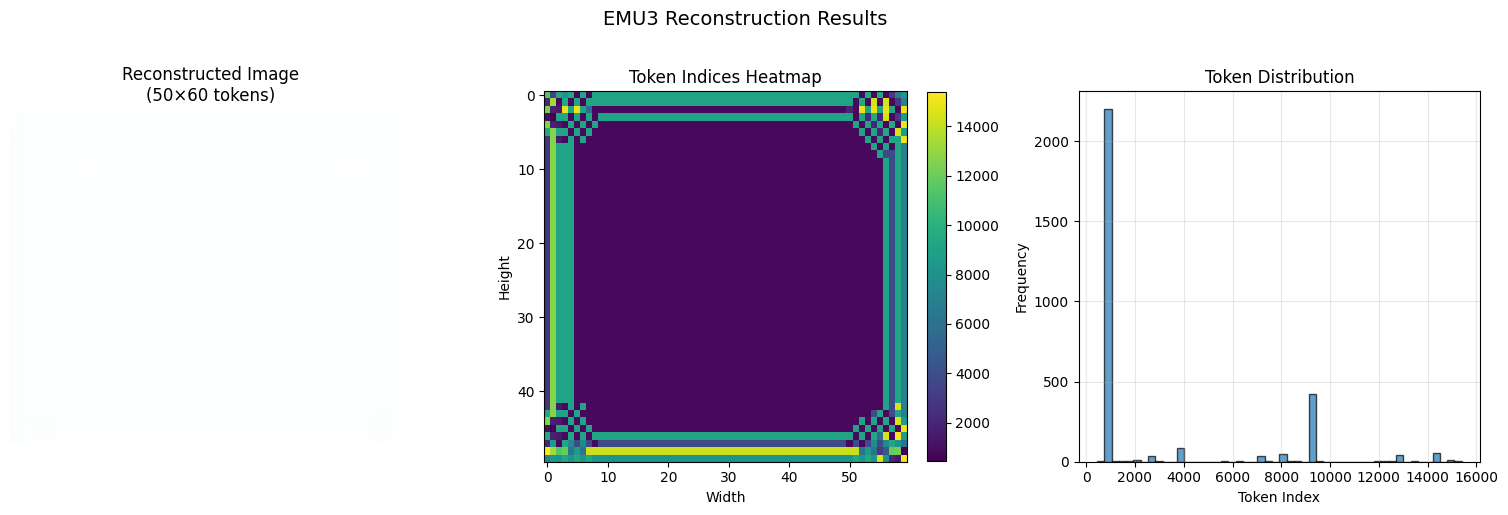


💾 Saved to reconstructed_50x60.png

GPU Memory Status After Reconstruction:
  GPU 0: 8.8GB free / 94.5GB total
  GPU 1: 88.9GB free / 94.5GB total
  GPU 2: 87.8GB free / 94.5GB total
  GPU 3: 88.9GB free / 94.5GB total


In [6]:
# Decode generated visual tokens back to image

from Tokenizer.Emu3VisionTokenizer import Emu3VisionTokenizer

# Check if we have consistent structure for reconstruction
if 'stats' in locals() and stats['consistent'] and stats['shape']:
    height, width = stats['shape']
    
    # Flatten rows to get all visual indices
    visual_indices = [idx for row in rows for idx in row]
    
    print(f"Reconstructing {height}×{width} image from {len(visual_indices)} tokens...")
    print("="*60)
    
    # Check GPU memory status
    print("\nGPU Memory Status:")
    for i in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(i)
        print(f"  GPU {i}: {free/1024**3:.1f}GB free / {total/1024**3:.1f}GB total")
    
    # Choose a GPU with enough free memory for EMU3 (need ~3-4GB)
    # Avoid GPU 0 since LLaMA is there
    best_gpu = 1  # Default to GPU 1
    max_free = 0
    for i in range(1, torch.cuda.device_count()):  # Start from GPU 1, skip GPU 0
        free, _ = torch.cuda.mem_get_info(i)
        if free > max_free:
            max_free = free
            best_gpu = i
    
    emu3_device = f"cuda:{best_gpu}"
    print(f"\nUsing {emu3_device} for EMU3 Vision Tokenizer (has {max_free/1024**3:.1f}GB free)")
    
    try:
        # Initialize EMU3 Vision Tokenizer (it will load on cuda:0 by default)
        print(f"Loading EMU3 Vision Tokenizer...")
        tokenizer = Emu3VisionTokenizer()  # Let it load on default device first
        
        # NOW MOVE THE MODEL TO THE TARGET DEVICE
        print(f"Moving model from cuda:0 to {emu3_device}...")
        tokenizer.model = tokenizer.model.to(emu3_device)
        tokenizer.device = emu3_device  # Update the device attribute
        
        # Verify the device
        actual_device = next(tokenizer.model.parameters()).device
        print(f"✓ Vision tokenizer now on: {actual_device}")
        
        # Create indices tensor directly on the correct device
        indices_tensor = torch.tensor(visual_indices, dtype=torch.long, device=actual_device)
        indices_tensor = indices_tensor.reshape(1, height, width)
        print(f"Indices tensor created on: {actual_device}")
        print(f"Indices tensor shape: {indices_tensor.shape}")
        
        # Decode to image
        print("\nDecoding visual tokens to image...")
        with torch.no_grad():
            reconstructed_tensor = tokenizer.decode(indices_tensor)
        
        # Convert to PIL image (postprocess handles CPU conversion)
        reconstructed_pil = tokenizer.postprocess(reconstructed_tensor)
        print(f"✅ Successfully reconstructed image: {reconstructed_pil.size}")
        
        # Clean up tokenizer to free GPU memory
        del tokenizer
        torch.cuda.empty_cache()
        gc.collect()
        print(f"Freed memory on {emu3_device}")
        
        # Visualize
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Reconstructed image
        axes[0].imshow(reconstructed_pil)
        axes[0].set_title(f"Reconstructed Image\n({height}×{width} tokens)")
        axes[0].axis('off')
        
        # Token grid heatmap
        token_grid = np.array(visual_indices).reshape(height, width)
        im = axes[1].imshow(token_grid, cmap='viridis', aspect='auto')
        axes[1].set_title("Token Indices Heatmap")
        axes[1].set_xlabel("Width")
        axes[1].set_ylabel("Height")
        plt.colorbar(im, ax=axes[1], fraction=0.046)
        
        # Token distribution
        axes[2].hist(visual_indices, bins=50, edgecolor='black', alpha=0.7)
        axes[2].set_title("Token Distribution")
        axes[2].set_xlabel("Token Index")
        axes[2].set_ylabel("Frequency")
        axes[2].grid(True, alpha=0.3)
        
        plt.suptitle(f"EMU3 Reconstruction Results", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Save
        save_path = f"reconstructed_{height}x{width}.png"
        reconstructed_pil.save(save_path)
        print(f"\n💾 Saved to {save_path}")
        
        # Show memory status after cleanup
        print("\nGPU Memory Status After Reconstruction:")
        for i in range(torch.cuda.device_count()):
            free, total = torch.cuda.mem_get_info(i)
            print(f"  GPU {i}: {free/1024**3:.1f}GB free / {total/1024**3:.1f}GB total")
        
    except Exception as e:
        print(f"❌ Reconstruction failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ Cannot reconstruct - need to run structure analysis first or rows are inconsistent")

## 5. Conditional Image Generation - Complete from First Quarter

Test if the model can complete an image given the first quarter of real image tokens as context.

In [7]:
# Optional plot style change to match tex documents
plt.rcParams.update({
        "axes.labelsize": 20,  # Increased axis label size
        "xtick.labelsize": 16,  # Increased X tick label size
        "ytick.labelsize": 16,  # Increased Y tick label size
        "legend.fontsize": 16,  # Increased legend font size
        "figure.figsize": (9, 8),  # A more moderate height with a narrower width (balanced)
        "lines.linewidth": 2,  # Lines thickness
        "axes.linewidth": 1.0,  # Axis line thickness
        "legend.title_fontsize": 18,  # Increased legend title size
        "axes.titlesize": 18,  # Increased title size
        "axes.titleweight": 'bold',  # Bold title
        "font.family": "serif",  # Ensures consistent font across plots
    })

CONDITIONAL IMAGE GENERATION (512×512)

1. Loading: cute_dog.jpg
   Original: (800, 534)
   Resized:  (512, 512)
Loading Emu3VisionTokenizer from BAAI/Emu3-VisionTokenizer...


✓ Emu3VisionTokenizer loaded successfully
Emu3VisionTokenizer loaded:
  Total parameters: 270.74M (270,740,287)
  Trainable parameters: 270.74M (270,740,287)

2. Tokenizing...


/tmp/ipykernel_252163/1619097934.py:74: DeprecationWarning: The keyword arguments {'prompt_token_ids'} are deprecated and will be removed in a future update. Please use the 'prompts' parameter instead.
  result = inferencer.generate(


   Tokens: 64×64

3. Creating prompt with first 55 rows...
   Given: 55 rows (3520 tokens)
   Need:  9 more rows (576 tokens)

4. Generating completion...


Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.78s/it, est. speed input: 1288.28 toks/s, output: 211.17 toks/s]


   Generated 576 tokens
   Generated 9 rows

5. Total: 64 rows × 64 cols = 4096 tokens

6. Reconstructing images...
   ✅ Reconstructed full: 64×64, generated-only: 9×64


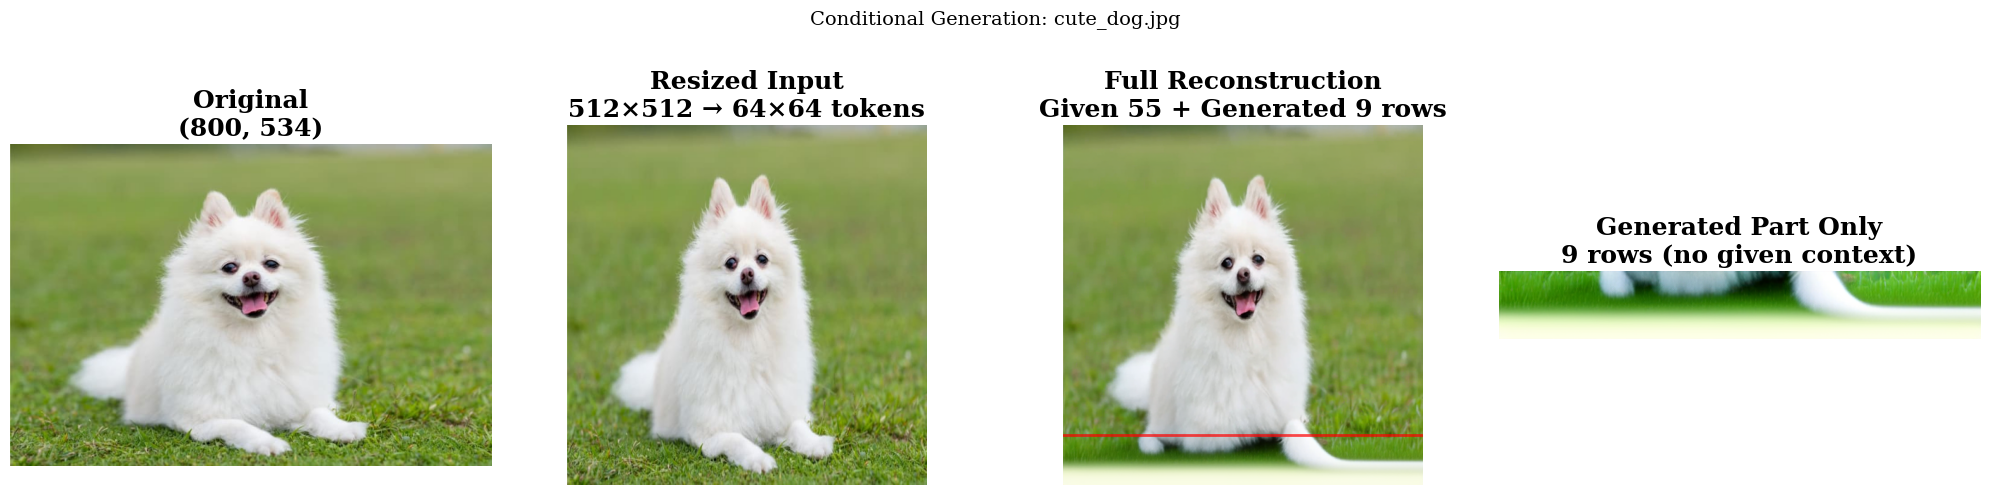


7. Comparing with ground truth...


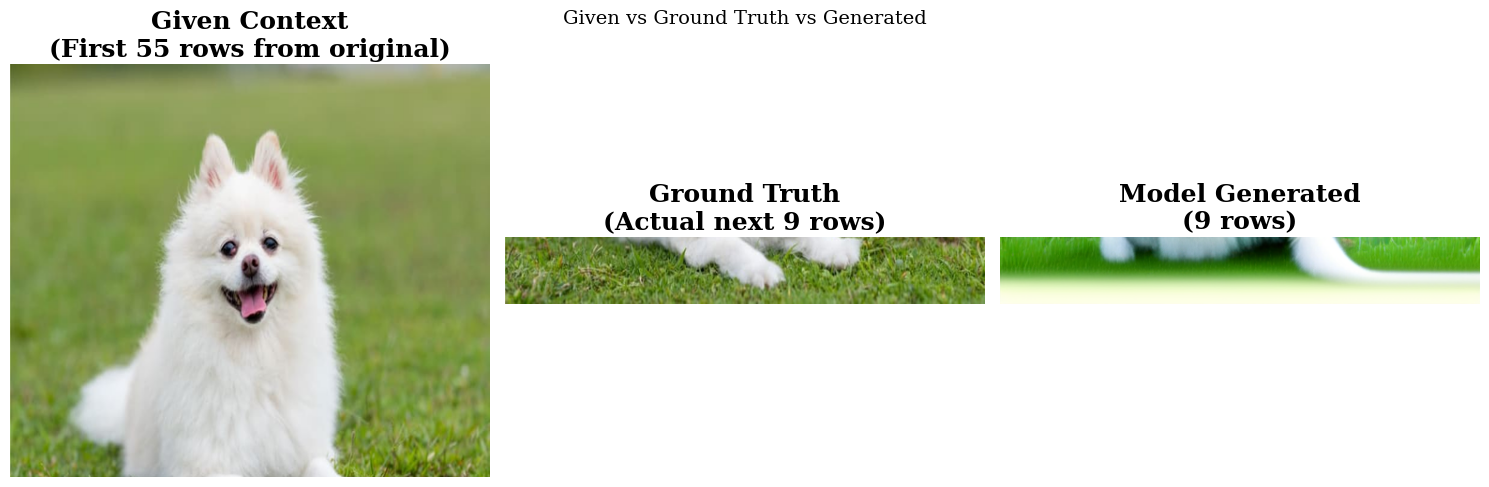


💾 Saved: reconstructed_55rows_0.1tmp_cute_dog.jpg and generated_only_55rows_0.1tmp_cute_dog.jpg


In [8]:
# Conditional generation with fixed 512x512 resize - focus on image reconstruction
from PIL import Image
from emu3_reconstruct_helper import extract_visual_tokens_by_row

# Configuration
image_paths = [
    f"{current_project_path}/assets/original/logo1.png",
    f"{current_project_path}/assets/original/line_chart.png",
    f"{current_project_path}/assets/original/math_draft1.png",
    f"{current_project_path}/assets/original/building.jpg",
    f"{current_project_path}/assets/original/checkerboard_pattern.png",
    f"{current_project_path}/assets/original/cute_dog.jpg",
    f"{current_project_path}/assets/original/3objects.png"
]

# Select image and settings
SELECTED_IMG = image_paths[5]  # Change index to test different images
given_rows = 55  # Given rows as context. For EMU3 one token is 8x8 pixels, so 55 rows = 440 pixels
target_size = 512  # Fixed 512x512 pixels → 64x64 tokens
GEN_TEMP = 0.1  # Generation temperature

print("="*80)
print("CONDITIONAL IMAGE GENERATION (512×512)")
print("="*80)

# 1. Load and resize to 512x512
print(f"\n1. Loading: {SELECTED_IMG.split('/')[-1]}")
img = Image.open(SELECTED_IMG).convert('RGB')
print(f"   Original: {img.size}")

img_resized = img.resize((target_size, target_size), Image.LANCZOS)
print(f"   Resized:  {img_resized.size}")

# Load tokenizer if needed
if 'tokenizer' not in locals():
    from Tokenizer.Emu3VisionTokenizer import Emu3VisionTokenizer
    tokenizer = Emu3VisionTokenizer(
        min_pixels=512 * 512,
        max_pixels=1024 * 1024
    )
    tokenizer.model = tokenizer.model.to("cuda:1")
    tokenizer.device = "cuda:1"

# 2. Tokenize
print("\n2. Tokenizing...")
img_tensor = tokenizer.preprocess(img_resized)
img_tensor = img_tensor.to(tokenizer.device)

with torch.no_grad():
    indices, _ = tokenizer.encode(img_tensor)

h, w = indices.shape[1], indices.shape[2]
visual_indices = indices[0].flatten().cpu().tolist()
print(f"   Tokens: {h}×{w}")

# 3. Create prompt with first N rows
print(f"\n3. Creating prompt with first {given_rows} rows...")
prompt = f"<|begin_of_text|><|img_start|>{h}*{w}<|img_token_start|>"

for row in range(given_rows):
    row_start = row * w
    row_end = row_start + w
    row_tokens = visual_indices[row_start:row_end]
    
    for token_idx in row_tokens:
        prompt += f"<|visual token {token_idx:06d}|>"
    prompt += "<|img_end_of_row|>"

print(f"   Given: {given_rows} rows ({given_rows * w} tokens)")
print(f"   Need:  {h - given_rows} more rows ({(h - given_rows) * w} tokens)")

# 4. Generate
print("\n4. Generating completion...")
result = inferencer.generate(
    prompt,
    max_tokens=(h - given_rows) * w + 200,
    temperature=GEN_TEMP
)

print(f"   Generated {result['num_visual_tokens']} tokens")

# 5. Extract and combine
rows_gen, stats_gen = extract_visual_tokens_by_row(
    result['generated_token_ids'],
    inferencer.vision_mapping,
    inferencer.special_token_ids
)

print(f"   Generated {stats_gen['num_rows']} rows")

# Combine tokens
given_indices = visual_indices[:given_rows * w]
generated_indices = [idx for row in rows_gen for idx in row]
all_indices = given_indices + generated_indices

total_rows = given_rows + stats_gen['num_rows']
print(f"\n5. Total: {total_rows} rows × {w} cols = {len(all_indices)} tokens")

# 6. Reconstruct both full image and generated-only part
if len(all_indices) >= total_rows * w and len(generated_indices) > 0:
    print("\n6. Reconstructing images...")
    try:
        # Full reconstruction (given + generated)
        indices_tensor_full = torch.tensor(all_indices[:total_rows * w], dtype=torch.long, device=tokenizer.device)
        indices_tensor_full = indices_tensor_full.reshape(1, total_rows, w)
        
        with torch.no_grad():
            reconstructed_full = tokenizer.decode(indices_tensor_full)
        reconstructed_full_pil = tokenizer.postprocess(reconstructed_full)
        
        # Generated-only reconstruction
        # Pad generated tokens to make a valid image
        gen_rows = stats_gen['num_rows']
        if gen_rows > 0 and len(generated_indices) == gen_rows * w:
            indices_tensor_gen = torch.tensor(generated_indices, dtype=torch.long, device=tokenizer.device)
            indices_tensor_gen = indices_tensor_gen.reshape(1, gen_rows, w)
            
            with torch.no_grad():
                reconstructed_gen = tokenizer.decode(indices_tensor_gen)
            reconstructed_gen_pil = tokenizer.postprocess(reconstructed_gen)
            print(f"   ✅ Reconstructed full: {total_rows}×{w}, generated-only: {gen_rows}×{w}")
        else:
            reconstructed_gen_pil = None
            print(f"   ✅ Reconstructed full: {total_rows}×{w}")
        
        # Visualize
        if reconstructed_gen_pil:
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        else:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Original
        axes[0].imshow(img)
        axes[0].set_title(f"Original\n{img.size}")
        axes[0].axis('off')
        
        # Resized input
        axes[1].imshow(img_resized)
        axes[1].set_title(f"Resized Input\n512×512 → {h}×{w} tokens")
        axes[1].axis('off')
        
        # Full reconstruction
        axes[2].imshow(reconstructed_full_pil)
        axes[2].set_title(f"Full Reconstruction\nGiven {given_rows} + Generated {gen_rows} rows")
        axes[2].axis('off')
        # Add red line to show boundary
        axes[2].axhline(y=given_rows * 8, color='red', linewidth=2, alpha=0.7)
        
        # Generated-only part
        if reconstructed_gen_pil:
            axes[3].imshow(reconstructed_gen_pil)
            axes[3].set_title(f"Generated Part Only\n{gen_rows} rows (no given context)")
            axes[3].axis('off')
        
        plt.suptitle(f"Conditional Generation: {SELECTED_IMG.split('/')[-1]}", fontsize=14)
        plt.tight_layout()
        plt.subplots_adjust(top=0.75)
        plt.show()
        
        # Compare given vs generated portion from original
        print("\n7. Comparing with ground truth...")
        fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
        
        # Show the given portion from original
        given_portion = img_resized.crop((0, 0, 512, given_rows * 8))
        axes2[0].imshow(given_portion)
        axes2[0].set_title(f"Given Context\n(First {given_rows} rows from original)")
        axes2[0].axis('off')
        
        # Show what should have been generated (ground truth)
        ground_truth_portion = img_resized.crop((0, given_rows * 8, 512, 512))
        axes2[1].imshow(ground_truth_portion)
        axes2[1].set_title(f"Ground Truth\n(Actual next {h - given_rows} rows)")
        axes2[1].axis('off')
        
        # Show what was actually generated
        if reconstructed_gen_pil:
            axes2[2].imshow(reconstructed_gen_pil)
            axes2[2].set_title(f"Model Generated\n({gen_rows} rows)")
            axes2[2].axis('off')
        
        plt.suptitle("Given vs Ground Truth vs Generated", fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Save
        save_path = f"reconstructed_{given_rows}rows_{GEN_TEMP}tmp_{SELECTED_IMG.split('/')[-1]}"
        abbox = axes[2].get_tightbbox(fig.canvas.get_renderer())
        fig.savefig(save_path, bbox_inches=abbox.transformed(fig.dpi_scale_trans.inverted()))
        if reconstructed_gen_pil:
            save_path_gen = f"generated_only_{given_rows}rows_{GEN_TEMP}tmp_{SELECTED_IMG.split('/')[-1]}"
            reconstructed_gen_pil.save(save_path_gen)
            print(f"\n💾 Saved: {save_path} and {save_path_gen}")
        else:
            print(f"\n💾 Saved: {save_path}")
        
    except Exception as e:
        print(f"❌ Failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"⚠️ Not enough tokens for reconstruction")

In [9]:
print(f"Vision Token Vocabulary range: {min(inferencer.vision_mapping.values())} - {max(inferencer.vision_mapping.values())}")
print(f"Special Tokens: {inferencer.special_token_ids}")

Vision Token Vocabulary range: 128361 - 161128
Special Tokens: {'img_start': 128256, 'img_end': 128257, 'img_token_start': 128258, 'img_end_of_row': 128259, 'img_end_of_frame': 128260}


/tmp/ipykernel_252163/1390826297.py:68: DeprecationWarning: The keyword arguments {'prompt_token_ids'} are deprecated and will be removed in a future update. Please use the 'prompts' parameter instead.
  result = inferencer.generate(


IMAGE-TO-TEXT GENERATION

1. Loading image: 3objects.png
   Original size: (640, 356)
   Resized to: (512, 512)

2. Tokenizing entire image...
   Token dimensions: 64×64 = 4096 tokens

3. Creating prompt with full image as context...

4. Generating text description...


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00, 12.38it/s, est. speed input: 51674.64 toks/s, output: 86.69 toks/s]



5. Extracting generated text...
Generated token ids: [18, 2204, 14098, 449, 2204, 8146, 128001]
Text starts at index 0 (token id 18)

GENERATED DESCRIPTION:
3 different fruit with different colors<|end_of_text|>


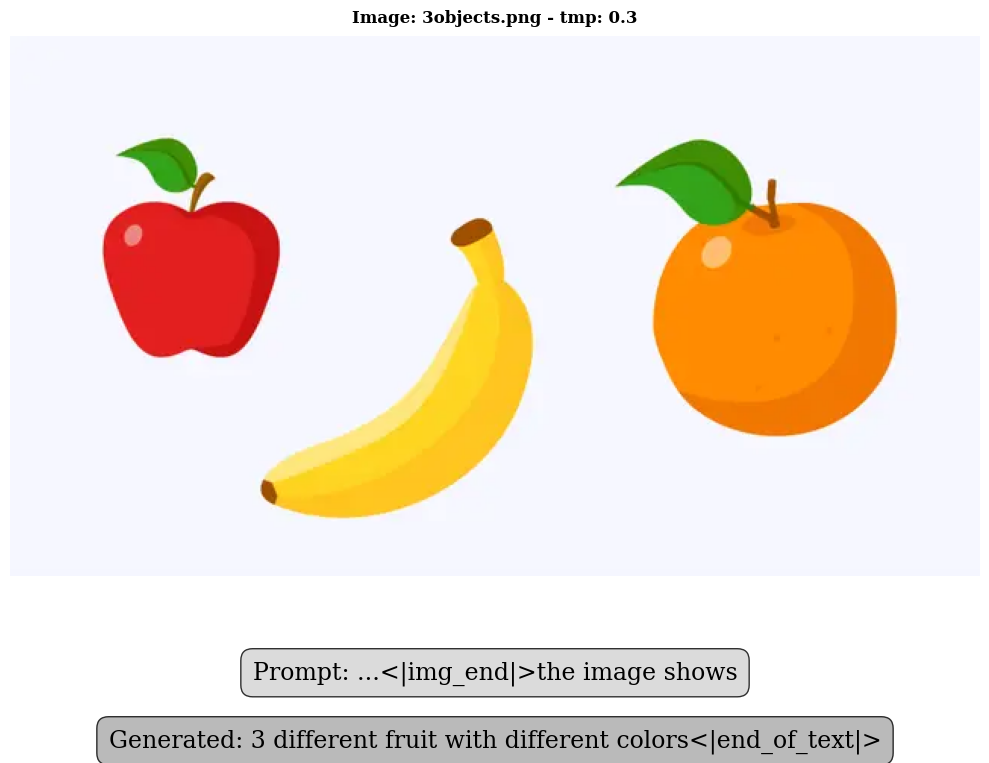


💾 Saved: textgen_0.3tmp_3objects.png

📊 Generation Statistics:
   Total tokens generated: 7
   Text tokens: 7
   Visual tokens in output: 0
   Text length: 6 words


In [10]:
# Image-to-Text Generation: Conditioning on entire image to generate text
from PIL import Image
from emu3_reconstruct_helper import extract_visual_tokens_by_row
import torch

print("="*80)
print("IMAGE-TO-TEXT GENERATION")
print("="*80)

# Select image
SELECTED_IMG = image_paths[6]  # Change index to test different images
target_size = 512  # Fixed 512x512 pixels → 64x64 tokens
GEN_TEMP = 0.3  # Generation temperature
SAVE_TO_DISK = True  # Whether to save results

print(f"\n1. Loading image: {SELECTED_IMG.split('/')[-1]}")
img = Image.open(SELECTED_IMG).convert('RGB')
print(f"   Original size: {img.size}")

# Resize to 512x512 for consistent tokenization
img_resized = img.resize((target_size, target_size), Image.LANCZOS)
print(f"   Resized to: {img_resized.size}")

# Load tokenizer if not already loaded
if 'tokenizer' not in locals():
    from Tokenizer.Emu3VisionTokenizer import Emu3VisionTokenizer
    tokenizer = Emu3VisionTokenizer(
        min_pixels=512 * 512,
        max_pixels=512 * 512
    )
    tokenizer.model = tokenizer.model.to("cuda:1")
    tokenizer.device = "cuda:1"
    print("   ✓ Tokenizer loaded on cuda:1")

# Tokenize the entire image
print("\n2. Tokenizing entire image...")
img_tensor = tokenizer.preprocess(img_resized)
img_tensor = img_tensor.to(tokenizer.device)

with torch.no_grad():
    indices, _ = tokenizer.encode(img_tensor)

h, w = indices.shape[1], indices.shape[2]
visual_indices = indices[0].flatten().cpu().tolist()
print(f"   Token dimensions: {h}×{w} = {len(visual_indices)} tokens")

# Create prompt with the ENTIRE image followed by text generation request
print("\n3. Creating prompt with full image as context...")
prompt = f"<|begin_of_text|><|img_start|>{h}*{w}<|img_token_start|>"

# Add all image tokens
for row in range(h):
    row_start = row * w
    row_end = row_start + w
    row_tokens = visual_indices[row_start:row_end]
    
    for token_idx in row_tokens:
        prompt += f"<|visual token {token_idx:06d}|>"
    prompt += "<|img_end_of_row|>"

# End image and add text prompt
prompt += "<|img_end_of_frame|><|img_end|>"
prompt += "the image shows "  # Start of text generation


# Generate text description
print("\n4. Generating text description...")
result = inferencer.generate(
    prompt,
    max_tokens=25,  # Generate up to 500 text tokens
    min_tokens=5,
    temperature=GEN_TEMP,  # Higher temperature for more creative text
    top_p=0.9
)

# Extract text from generated tokens
print("\n5. Extracting generated text...")
generated_ids = result['generated_token_ids']
print(f"Generated token ids: {generated_ids}")

# Find where text starts (after the prompt)
text_start_idx = 0
for i, token_id in enumerate(generated_ids):
    if token_id not in inferencer.vision_mapping.values() and token_id not in inferencer.special_token_ids.values():
        text_start_idx = i
        print(f"Text starts at index {text_start_idx} (token id {token_id})")
        break

# Decode text tokens
text_ids = [tid for tid in generated_ids[text_start_idx:] 
            if tid not in inferencer.vision_mapping.values() 
            and tid not in inferencer.special_token_ids.values()]

generated_text = inferencer.tokenizer.decode(text_ids)

print("\n" + "="*80)
print("GENERATED DESCRIPTION:")
print("="*80)
print(generated_text)
print("="*80)

# Visualize image with generated caption
import matplotlib.pyplot as plt
import textwrap

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Show the image
ax.imshow(img)
ax.axis('off')

# Add the generated text as caption
wrapped_text = textwrap.fill(f"Generated: {generated_text}", width=80)
ax.set_title(f"Image: {SELECTED_IMG.split('/')[-1]} - tmp: {GEN_TEMP}", fontsize=12, pad=10)

# Add Text above the image
fig.text(0.5, 0.1, f"Prompt: ...<|img_end|>the image shows", ha='center', fontsize=17, 
         wrap=True, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

# Add text below the image
fig.text(0.5, 0.015, wrapped_text, ha='center', fontsize=17, 
         wrap=True, bbox=dict(boxstyle="round,pad=0.5", facecolor="darkgray", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for text
plt.show()

# Save
if SAVE_TO_DISK:
    save_path = f"textgen_{GEN_TEMP}tmp_{SELECTED_IMG.split('/')[-1]}"
    fig.savefig(save_path, bbox_inches='tight')
    print(f"\n💾 Saved: {save_path}")

print(f"\n📊 Generation Statistics:")
print(f"   Total tokens generated: {len(result['generated_token_ids'])}")
print(f"   Text tokens: {len(text_ids)}")
print(f"   Visual tokens in output: {result['num_visual_tokens']}")
print(f"   Text length: {len(generated_text.split())} words")